## Phase 3: Heston Stochastic Volatility Model Implementation

Task 3.1: Implement the Heston Characteristic Function:

    Following the formulas in Section 4.2 of the provided paper, write a Python function that calculates the value of the characteristic function f_j for the Heston model. This function will be complex-valued.

In [44]:
import numpy as np
import pandas as pd
import warnings
from scipy.integrate import quad
from scipy.stats import norm

def heston_char_func(phi, S, T, r, v0, kappa, theta, sigma_v, rho, j, q=0.013):
    """
    Uses the "Little Heston Trap" formulation for numerical stability.

    Parameters:
    phi: float or array - Pourier variable
    S: float - Spot price
    T: float - Time to maturity
    r: float - Risk-free rate
    v0: float - Initial variance
    kappa: float - Mean reversion rate
    theta: float - Long-run variance
    sigma_v: float - Volatility of variance
    rho: float - Correlation between asset and variance
    j: int - 1 or 2 (selects u_j, b_j)
    q: float - Continuous dividend yield (default 0.013 for SPY)
    """

    x = np.log(S)
    tau = T

    # Lambda = 0 (market price of volatility risk, set to zero under risk-neutral measure)
    lam = 0.0

    # Parameters that differ between j=1 and j=2
    if j == 1:
        u = 0.5
        b = kappa + lam - rho * sigma_v
    else:
        u = -0.5
        b = kappa + lam

    a = kappa * theta
    sigma2 = sigma_v ** 2

    d = np.sqrt((rho * sigma_v * phi * 1j - b) ** 2 - sigma2 * (2 * u * phi * 1j - phi ** 2))

    # Little Heston Trap formulation
    g = (b - rho * sigma_v * phi * 1j - d) / (b - rho * sigma_v * phi * 1j + d)

    exp_neg_d_tau = np.exp(-d * tau)
    D = (b - rho * sigma_v * phi * 1j - d) / sigma2 * (1 - exp_neg_d_tau) / (1 - g * exp_neg_d_tau)

    C = ((r - q) * phi * 1j * tau + a / sigma2 * ((b - rho * sigma_v * phi * 1j - d) * tau - 2 * np.log((1 - g * exp_neg_d_tau) / (1 - g))))

    return np.exp(C + D * v0 + 1j * phi * x)

Tests

In [45]:
def test_char_func():
    # (from Table 1 in Karlsson paper)
    S = 100.0
    T = 1.0
    r = 0.05
    v0 = 0.16
    kappa = 10.0
    theta = 0.16
    sigma_v = 0.10
    rho = -0.80

    # Test 1: f_j(φ=0) should equal 1
    f1_0 = heston_char_func(0.0, S, T, r, v0, kappa, theta, sigma_v, rho, j=1, q=0.0)
    f2_0 = heston_char_func(0.0, S, T, r, v0, kappa, theta, sigma_v, rho, j=2, q=0.0)

    print("\nTest 1: f_j(φ=0) = 1")
    print(f"f1(0) = {f1_0:.10f}  (expect 1.0)")
    print(f"f2(0) = {f2_0:.10f}  (expect 1.0)")
    assert abs(f1_0 - 1.0) < 1e-12, f"f1(0) = {f1_0}, expected 1.0"
    assert abs(f2_0 - 1.0) < 1e-12, f"f2(0) = {f2_0}, expected 1.0"
    print("PASSED")

    # Test 2: |f_j(φ)| ≤ 1 for all φ > 0
    phis = np.linspace(0.01, 200, 1000)
    for j in [1, 2]:
        vals = np.array([heston_char_func(p, S, T, r, v0, kappa, theta,
                                          sigma_v, rho, j=j, q=0.0) for p in phis])
        max_mod = np.max(np.abs(vals))
        print(f"\nTest 2.{j}: |f{j}(φ)| ≤ 1 for φ ∈ [0.01, 200]")
        print(f"max |f{j}| = {max_mod:.8f}")
        assert max_mod < 1.0 + 1e-6, f"max |f{j}| = {max_mod} > 1"
        print("PASSED")

    # Test 3: f_j(φ) => 0 as φ => ∞  (Riemann-Lebesgue lemma)
    for j in [1, 2]:
        f_large = heston_char_func(500.0, S, T, r, v0, kappa, theta,
                                   sigma_v, rho, j=j, q=0.0)
        print(f"\nTest 3.{j}: f{j}(φ=500) => 0  (decay check)")
        print(f"|f{j}(500)| = {abs(f_large):.2e}")
        assert abs(f_large) < 1e-3, f"|f{j}(500)| = {abs(f_large)} not small"
        print("PASSED")

    # Test 4: Continuity — no jumps (Little Heston Trap verification)
    phis_fine = np.linspace(0.01, 300, 5000)
    for j in [1, 2]:
        vals = np.array([heston_char_func(p, S, T, r, v0, kappa, theta,
                                          sigma_v, rho, j=j, q=0.0) for p in phis_fine])
        mods = np.abs(vals)
        max_jump = np.max(np.abs(np.diff(mods)))
        print(f"\nTest 4.{j}: Continuity of |f{j}(φ)|  (branch-cut test)")
        print(f"max consecutive jump in |f{j}| = {max_jump:.2e}")
        assert max_jump < 0.05, f"Discontinuity detected: jump = {max_jump}"
        print("PASSED")

    # Test 5: Conjugate symmetry f_j(-φ) = conj(f_j(φ))
    phi_test = 5.0
    for j in [1, 2]:
        f_pos = heston_char_func(phi_test, S, T, r, v0, kappa, theta,
                                 sigma_v, rho, j=j, q=0.0)
        f_neg = heston_char_func(-phi_test, S, T, r, v0, kappa, theta,
                                 sigma_v, rho, j=j, q=0.0)
        diff = abs(f_neg - np.conj(f_pos))
        print(f"\nTest 5.{j}: f{j}(-φ) = conj(f{j}(φ))  at φ = {phi_test}")
        print(f"f{j}({phi_test})  = {f_pos:.8f}")
        print(f"f{j}(-{phi_test}) = {f_neg:.8f}")
        print(f"conj(f{j}({phi_test})) = {np.conj(f_pos):.8f}")
        print(f"|difference| = {diff:.2e}")
        assert diff < 1e-10, f"Conjugate symmetry violated: diff = {diff}"
        print("PASSED")

    # Test 6: BS limit — when σ_v => 0 and v0 = θ = σ², Heston reduces to BS
    sigma_bs = 0.20
    v0_bs = sigma_bs ** 2
    theta_bs = v0_bs
    sigma_v_tiny = 1e-6
    kappa_bs = 5.0
    rho_bs = 0.0

    phi_test = 3.0
    for j in [1, 2]:
        f_bs = heston_char_func(phi_test, S, T, r, v0_bs, kappa_bs, theta_bs,
                                sigma_v_tiny, rho_bs, j=j, q=0.0)
        print(f"\nTest 6.{j}: BS limit (sigma_v => 0, v0 = θ = {v0_bs})")
        print(f"f{j}(φ={phi_test}) = {f_bs:.8f}")
        print(f"|f{j}| = {abs(f_bs):.8f}  (should be finite, < 1)")
        assert np.isfinite(f_bs), f"f{j} not finite in BS limit"
        assert abs(f_bs) <= 1.0 + 1e-6, f"|f{j}| > 1 in BS limit"
        print("PASSED")


if __name__ == "__main__":
    test_char_func()


Test 1: f_j(φ=0) = 1
f1(0) = 1.0000000000+0.0000000000j  (expect 1.0)
f2(0) = 1.0000000000+0.0000000000j  (expect 1.0)
PASSED

Test 2.1: |f1(φ)| ≤ 1 for φ ∈ [0.01, 200]
max |f1| = 0.99999211
PASSED

Test 2.2: |f2(φ)| ≤ 1 for φ ∈ [0.01, 200]
max |f2| = 0.99999194
PASSED

Test 3.1: f1(φ=500) => 0  (decay check)
|f1(500)| = 0.00e+00
PASSED

Test 3.2: f2(φ=500) => 0  (decay check)
|f2(500)| = 0.00e+00
PASSED

Test 4.1: Continuity of |f1(φ)|  (branch-cut test)
max consecutive jump in |f1| = 1.44e-02
PASSED

Test 4.2: Continuity of |f2(φ)|  (branch-cut test)
max consecutive jump in |f2| = 1.46e-02
PASSED

Test 5.1: f1(-φ) = conj(f1(φ))  at φ = 5.0
f1(5.0)  = 0.02514244-0.13744527j
f1(-5.0) = 0.02514244+0.13744527j
conj(f1(5.0)) = 0.02514244+0.13744527j
|difference| = 0.00e+00
PASSED

Test 5.2: f2(-φ) = conj(f2(φ))  at φ = 5.0
f2(5.0)  = -0.07706715-0.10948086j
f2(-5.0) = -0.07706715+0.10948086j
conj(f2(5.0)) = -0.07706715+0.10948086j
|difference| = 0.00e+00
PASSED

Test 6.1: BS limit (sigma

Task 3.2: Implement the Heston Pricing Integral:

    Write a main pricing function that calculates the Heston model option price. This function will use numerical integration (e.g., scipy.integrate.quad) to evaluate the integrals for P1 and P2 from the paper's pricing formula.
    This function will take S, K, T, r, and the five Heston parameters (v0, kappa, theta, sigma_v, rho) as inputs.

In [46]:
def heston_price(S, K, T, r, v0, kappa, theta, sigma_v, rho, option_type='call', q=0.013):
    """
    Heston European option price via numerical integration.

    Parameters:
    S - Spot price
    K - Strike price
    T - Time to maturity
    r - Risk-free rate
    v0 - Initial variance
    kappa - Mean reversion rate
    theta - Long-run variance
    sigma_v - Volatility of variance
    rho - Correlation between asset and variance
    option_type - 'call' or 'put'
    q - Continuous dividend yield (default 0.013 for SPY)
    """

    ln_K = np.log(K)

    def integrand_j(phi, j):
        # Real part of the Fourier integrand for P_j
        f = heston_char_func(phi, S, T, r, v0, kappa, theta, sigma_v, rho, j, q)
        return np.real(np.exp(-1j * phi * ln_K) * f / (1j * phi))

    # Numerical integration over [0, ∞)
    # quad with limit=np.inf uses a transformation to handle the infinite range
    # Suppress IntegrationWarning for edge cases (σ_v ≈ 0); results stay accurate.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        P1_integral, _ = quad(integrand_j, 1e-8, np.inf, args=(1,),
                              limit=200, epsabs=1e-10, epsrel=1e-10)
        P2_integral, _ = quad(integrand_j, 1e-8, np.inf, args=(2,),
                              limit=200, epsabs=1e-10, epsrel=1e-10)

    P1 = 0.5 + P1_integral / np.pi
    P2 = 0.5 + P2_integral / np.pi

    call_price = S * np.exp(-q * T) * P1 - K * np.exp(-r * T) * P2

    if option_type == 'call':
        return max(call_price, 0.0)
    else:
        # Put via put-call parity: P = C - S + K * e^(-rT)
        put_price = call_price - S * np.exp(-q * T) + K * np.exp(-r * T)
        return max(put_price, 0.0)

# Black-Scholes price for comparison
def bs_price(S, K, T, r, sigma, option_type='call', q=0.013):
    if T < 1e-10:
        if option_type == "call":
            return max(S - K, 0.0)
        else:
            return max(K - S, 0.0)

    F = S * np.exp(-q * T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = F * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - F * norm.cdf(-d1)
        
    return price


Tests

In [47]:
def test_heston_pricing():
    # Karlsson paper parameters (Table 1)
    S = 100.0
    r = 0.05
    v0 = 0.16
    kappa = 10.0
    theta = 0.16
    sigma_v = 0.10
    rho = -0.80

    # Test 1: BS limit — when σ_v => 0, Heston ≈ BS
    print("\nTest 1: BS limit (sigma_v => 0)")
    sigma_bs = 0.20
    v0_bs = sigma_bs**2
    theta_bs = v0_bs
    sigma_v_tiny = 1e-6
    kappa_bs = 5.0
    rho_bs = 0.0

    test_cases_bs = [
        (100.0, 1.0), # ATM
        (90.0,  1.0), # ITM call
        (110.0, 1.0), # OTM call
        (100.0, 0.5), # short-term ATM
    ]

    print(f"{'K':>6} {'T':>5} {'Heston':>10} {'BS':>10} {'Diff':>10}")
    for K, T in test_cases_bs:
        h = heston_price(S, K, T, r, v0_bs, kappa_bs, theta_bs,
                         sigma_v_tiny, rho_bs, "call", q=0.0)
        b = bs_price(S, K, T, r, sigma_bs, "call", q=0.0)
        diff = abs(h - b)
        print(f"{K:>6.0f} {T:>5.1f} {h:>10.4f} {b:>10.4f} {diff:>10.6f}")
        assert diff < 0.01, f"BS limit failed: K={K}, T={T}, diff={diff:.6f}"
    print("All within 0.01 of BS")

    # Test 2: Fang-Oosterlee / Bakshi-Cao-Chen benchmark
    print("\nTest 2: Fang-Oosterlee / Bakshi-Cao-Chen benchmark")

    fo_c = heston_price(
        S=100.0, K=100.0, T=1.0, r=0.0,
        v0=0.0175, kappa=1.5768, theta=0.0398,
        sigma_v=0.5751, rho=-0.5711, option_type="call", q=0.0
    )
    ref = 5.7854
    diff = abs(fo_c - ref)
    print(f"Heston price = {fo_c:.6f}")
    print(f"Reference = {ref:.4f}")
    print(f"|Difference| = {diff:.6f}")
    assert diff < 0.001, f"Benchmark failed: diff = {diff:.6f}"
    print("Matches to 3 decimal places")

    # Test 3: Put-call parity  C - P = Se^(-qT) - K·e^(-rT), with q=0
    print("\nTest 3: Put-call parity")
    parity_tests = [
        (100.0, 1.0), # ATM
        (80.0,  0.5), # ITM call
        (120.0, 2.0), # OTM call, long-term
    ]
    print(f"{'K':>6} {'T':>5} {'C':>10} {'P':>10} {'C-P':>10} {'S-Ke^rT':>10} {'Err':>10}")
    for K, T in parity_tests:
        c = heston_price(S, K, T, r, v0, kappa, theta, sigma_v, rho, "call", q=0.0)
        p = heston_price(S, K, T, r, v0, kappa, theta, sigma_v, rho, "put", q=0.0)
        lhs = c - p
        rhs = S - K * np.exp(-r * T)
        err = abs(lhs - rhs)
        print(f"{K:>6.0f} {T:>5.1f} {c:>10.4f} {p:>10.4f} "
              f"{lhs:>10.4f} {rhs:>10.4f} {err:>10.2e}")
        assert err < 1e-6, f"Parity failed: K={K}, T={T}, err={err}"
    print("Parity holds to machine precision")

    # Test 4: No-arbitrage bounds
    print("\nTest 4: No-arbitrage bounds")
    bound_tests = [
        (80.0,  0.5), # deep ITM call
        (100.0, 1.0), # ATM
        (120.0, 1.0), # OTM call
        (100.0, 0.1), # short-term ATM
    ]
    all_ok = True
    for K, T in bound_tests:
        c = heston_price(S, K, T, r, v0, kappa, theta, sigma_v, rho, "call", q=0.0)
        p = heston_price(S, K, T, r, v0, kappa, theta, sigma_v, rho, "put", q=0.0)
        intrinsic_c = max(S - K * np.exp(-r * T), 0)
        pv_K = K * np.exp(-r * T)

        ok_c = (0 <= c <= S) and (c >= intrinsic_c - 1e-6)
        ok_p = (0 <= p <= pv_K + 1e-6)

        status = "OK" if (ok_c and ok_p) else "Fail"
        if not (ok_c and ok_p):
            all_ok = False
        print(f"K={K:>6.0f} T={T:.1f}:  C={c:>8.4f} in [{intrinsic_c:.4f}, {S:.0f}]  "
              f"P={p:>8.4f} in [0, {pv_K:.4f}] {status}")

    assert all_ok, "Arbitrage bound violation"
    print("All bounds satisfied")

    # Test 5: Sensitivity to rho (skew driver)
    print("\nTest 5: Sensitivity to rho (skew check)")
    K_test = 80.0
    T_test = 1.0
    rhos = [-0.8, 0.0, 0.8]
    prices = []
    for rho_test in rhos:
        c = heston_price(S, K_test, T_test, r, v0, kappa, theta,
                         sigma_v, rho_test, "call", q=0.0)
        prices.append(c)
        print(f"rho = {rho_test:>+5.1f}:  C(K={K_test:.0f}) = {c:.4f}")
    assert all(p > 0 for p in prices), "Negative price!"
    print("All prices positive, rho effect visible")

    # Test 6: Sensitivity to sigma_v (smile curvature driver)
    print("\nTest 6: Sensitivity to sigma_v (smile curvature)")
    K_otm = 120.0
    T_test = 1.0
    sigvs = [0.05, 0.20, 0.50, 1.00]
    print(f"  OTM call K={K_otm:.0f}, T={T_test}:")
    prev_price = None
    for sv in sigvs:
        c = heston_price(S, K_otm, T_test, r, v0, kappa, theta,
                         sv, rho, "call", q=0.0)
        direction = ""
        if prev_price is not None:
            direction = "up" if c > prev_price else "down"
        prev_price = c
        print(f"  sigma_v = {sv:.2f}:  C = {c:.4f}  {direction}")
    print("sigma_v changes OTM prices (smile curvature effect)")

if __name__ == "__main__":
    test_heston_pricing()


Test 1: BS limit (sigma_v => 0)
     K     T     Heston         BS       Diff
   100   1.0    10.4506    10.4506   0.000037
    90   1.0    16.6995    16.6994   0.000056
   110   1.0     6.0401     6.0401   0.000039
   100   0.5     6.8887     6.8887   0.000055
All within 0.01 of BS

Test 2: Fang-Oosterlee / Bakshi-Cao-Chen benchmark
Heston price = 5.785155
Reference = 5.7854
|Difference| = 0.000245
Matches to 3 decimal places

Test 3: Put-call parity
     K     T          C          P        C-P    S-Ke^rT        Err
   100   1.0    18.0112    13.1341     4.8771     4.8771   7.11e-15
    80   0.5    24.6294     2.6542    21.9752    21.9752   7.11e-15
   120   2.0    19.1088    27.6893    -8.5805    -8.5805   7.11e-15
Parity holds to machine precision

Test 4: No-arbitrage bounds
K=    80 T=0.5:  C= 24.6294 in [21.9752, 100]  P=  2.6542 in [0, 78.0248] OK
K=   100 T=1.0:  C= 18.0112 in [4.8771, 100]  P= 13.1341 in [0, 95.1229] OK
K=   120 T=1.0:  C= 10.7289 in [0.0000, 100]  P= 24.876

## Phase 4: Calibrating the Heston Model to Market Data

Task 4.1: Define the Calibration Objective Function:

    Write a function that takes the Heston parameters as a single vector/tuple.
    Inside this function, iterate through your market data (all options in the chain) and calculate the model price for each option using your Heston pricing function.
    Calculate the error between the model prices and the market prices.
    The function should return this single error value.

- Vectorized Heston characteristic function — processes entire φ-array at once

In [48]:
def _heston_char_func_vec(phi_arr, S, T, r, v0, kappa, theta, sigma_v, rho, j, q=0.013):
    x = np.log(S)
    tau = T
    phi = phi_arr

    if j == 1: 
        u, b = 0.5, kappa - rho * sigma_v
    else:
        u, b = -0.5, kappa

    a = kappa * theta
    sigma2 = sigma_v ** 2

    d = np.sqrt((rho * sigma_v * phi * 1j - b) ** 2 - sigma2 * (2 * u * phi * 1j - phi ** 2))

    g = (b - rho * sigma_v * phi * 1j - d) / (b - rho * sigma_v * phi * 1j + d)

    exp_neg_d_tau = np.exp(-d * tau)

    D = (b - rho * sigma_v * phi * 1j - d) / sigma2 * (1 - exp_neg_d_tau) / (1 - g * exp_neg_d_tau)

    C_val = ((r - q) * phi * 1j * tau + a / sigma2 * ((b - rho * sigma_v * phi * 1j - d) * tau - 2 * np.log((1 - g * exp_neg_d_tau) / (1 - g))))

    return np.exp(C_val + D * v0 + 1j * phi * x)


- Fast Heston pricer for calibration


In [49]:
def heston_price_vec(S, K, T, r, v0, kappa, theta, sigma_v, rho,
                     option_type='call', phi_grid=None, q=0.013):
    """
    Fast Heston pricer: vectorized char func + trapezoidal rule.

    Same formula as heston_price (Task 3.2), but uses fixed φ-grid
    instead of adaptive scipy.quad. ~2-3x faster per option.

    Pass pre-allocated phi_grid to avoid repeated allocation in loops.
    """

    if phi_grid is None:
        phi_grid = np.linspace(1e-8, 200.0, 2000)

    ln_K = np.log(K)

    # P1
    f1 = _heston_char_func_vec(phi_grid, S, T, r, v0, kappa, theta, sigma_v, rho, j=1, q=q)
    int1 = np.real(np.exp(-1j * phi_grid * ln_K) * f1 / (1j * phi_grid))
    P1 = 0.5 + np.trapezoid(int1, phi_grid) / np.pi

    # P2
    f2 = _heston_char_func_vec(phi_grid, S, T, r, v0, kappa, theta, sigma_v, rho, j=2, q=q)
    int2 = np.real(np.exp(-1j * phi_grid * ln_K) * f2 / (1j * phi_grid))
    P2 = 0.5 + np.trapezoid(int2, phi_grid) / np.pi

    call_price = S * np.exp(-q * T) * P1 - K * np.exp(-r * T) * P2

    if option_type == 'call':
        return max(call_price, 0.0)
    else:
        return max(call_price - S * np.exp(-q * T) + K * np.exp(-r * T), 0.0)

- BS Vega (for vega-weighting in objective)

In [50]:
def bs_vega(S, K, T, r, sigma, q=0.013):
    # BS vega: ∂C/∂σ = S·φ(d1)·√T  (same for calls and puts)

    if T < 1e-10 or sigma < 1e-10:
        return 0.0
    
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))

    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)

- Data preparation

In [51]:
def prepare_calibration_data(moneyness_range=(0.90, 1.10),
                             min_price=0.50):
    """
    Load and filter options data for Heston calibration.

    Returns DataFrame of OTM options:
    - calls where K/S > 1, puts where K/S ≤ 1
    - filtered for liquidity (moneyness range + min price)
    - adds vega-based weights
    """

    df = pd.read_csv('data/spy_options_enriched.csv')

    # Compute derived columns
    df["mid_price"] = (df["bid"] + df["ask"]) / 2
    df["moneyness"] = df["strike"] / df["S"]

    # OTM selection: calls K/S > 1, puts K/S ≤ 1
    otm_calls = df[(df['option_type'] == 'call') & (df['moneyness'] > 1.0)]
    otm_puts = df[(df['option_type'] == 'put') & (df['moneyness'] <= 1.0)]
    otm = pd.concat([otm_calls, otm_puts], ignore_index=True)

    # Liquidity filter
    mn_lo, mn_hi = moneyness_range
    mask = (
        (otm['moneyness'] >= mn_lo)
        & (otm['moneyness'] <= mn_hi)
        & (otm['mid_price'] >= min_price)
    )
    calib = otm[mask].copy().reset_index(drop=True)

    # Vega weights
    calib['bs_vega'] = calib.apply(
        lambda row: bs_vega(row['S'], row['strike'], row['T'],
                            row['r'], row['impliedVolatility']),
        axis=1
    )

    vega_sum = calib['bs_vega'].sum()
    if vega_sum > 0:
        calib['weight'] = calib['bs_vega'] / vega_sum * len(calib)
    else:
        calib['weight'] = 1.0  # fallback to equal weights if all vegas are zero

    return calib

- Objective function

In [52]:
def calibration_objective(params, market_data, phi_grid=None):
    """
    Heston calibration objective: weighted sum of squared relative price errors.

    Parameters:
    params - array-like [v0, kappa, theta, sigma_v, rho]
    market_data - DataFrame from prepare_calibration_data()
    phi_grid - pre-allocated φ grid (optional, for speed)
    """

    v0, kappa, theta, sigma_v, rho = params

    if (v0 <= 0 or kappa <= 0 or theta <= 0 or sigma_v <= 0
            or rho <= -1 or rho >= 1):
        return 1e10  # Penalize invalid params
    
    if phi_grid is None:
        phi_grid = np.linspace(1e-8, 200.0, 2000)

    total_error = 0.0
    n_failed = 0

    for _, row in market_data.iterrows():
        try:
            model_price = heston_price_vec(
                row['S'], row['strike'], row['T'], row['r'],
                v0, kappa, theta, sigma_v, rho,
                option_type=row['option_type'], phi_grid=phi_grid
            )
            rel_err = (model_price - row['mid_price']) / row['mid_price']
            total_error += row['weight'] * rel_err ** 2
        except Exception:
            n_failed += 1
            total_error += row['weight'] * 1.0  # Penalize failures with large error

    if n_failed > 0.1 * len(market_data):
        total_error += 1e6  # Penalize if too many failures

    return total_error

In [53]:
def calibration_objective_rmse(params, market_data, phi_grid=None):
    """
    Alternative: RMSE on absolute prices (for reporting, not optimization).
    """
    v0, kappa, theta, sigma_v, rho = params

    if (v0 <= 0 or kappa <= 0 or theta <= 0 or sigma_v <= 0
            or rho <= -1 or rho >= 1):
        return 1e10
    
    if phi_grid is None:
        phi_grid = np.linspace(1e-8, 200.0, 2000)

    sse = 0.0
    n = len(market_data)

    for _, row in market_data.iterrows():
        try:
            model_price = heston_price_vec(
                row['S'], row['strike'], row['T'], row['r'],
                v0, kappa, theta, sigma_v, rho,
                option_type=row['option_type'], phi_grid=phi_grid
            )
            sse += (model_price - row['mid_price']) ** 2
        except Exception:
            sse += row['mid_price'] ** 2

    return np.sqrt(sse / n)

- Tests

In [67]:
def test_task41():
    print("  Task 4.1: Calibration Objective Function — Tests")

    # 1. Data preparation
    print("\n[1] Preparing calibration data")
    calib = prepare_calibration_data()

    print(f"    Total OTM options: {len(calib)}")
    print(f"    Expiries: {calib['expiry'].nunique()}")
    print(f"    Moneyness: {calib['moneyness'].min():.3f} – "
          f"{calib['moneyness'].max():.3f}")
    print(f"    Price: ${calib['mid_price'].min():.2f} – "
          f"${calib['mid_price'].max():.2f}")

    print(f"\n    {'Expiry':<12} {'N':>4} {'T':>8} {'Calls':>6} {'Puts':>6}")
    for exp in sorted(calib["expiry"].unique()):
        sub = calib[calib["expiry"] == exp]
        nc = len(sub[sub["option_type"] == "call"])
        np_ = len(sub[sub["option_type"] == "put"])
        print(f"    {exp:<12} {len(sub):>4} {sub['T'].iloc[0]:>8.4f} "
              f"{nc:>6} {np_:>6}")

    phi_grid = np.linspace(1e-8, 200.0, 2000)

    # 2. Vectorized pricer matches quad-based
    print("\n[2] Accuracy: heston_price_vec vs heston_price (Task 3.2)")

    test_params = (0.04, 3.0, 0.04, 0.4, -0.65)
    S, r = 692.12, 0.037

    test_options = [
        (692.0, 0.10, "call"),
        (720.0, 0.35, "call"),
        (660.0, 0.60, "put"),
        (700.0, 1.35, "call"),
    ]

    print(f"    {'K':>6} {'T':>5} {'Type':>5} {'Vec':>10} {'Quad':>10} {'Diff':>10}")
    max_diff = 0.0
    for K, T, otype in test_options:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            p_vec = heston_price_vec(S, K, T, r, *test_params, otype, phi_grid)
            p_quad = heston_price(S, K, T, r, *test_params, otype)
        diff = abs(p_vec - p_quad)
        max_diff = max(max_diff, diff)
        print(f"    {K:>6.0f} {T:>5.2f} {otype:>5} {p_vec:>10.4f} "
              f"{p_quad:>10.4f} {diff:>10.6f}")
        print(f"max_diff = {max_diff}")
    assert max_diff < 0.05
    print("Matches quad-based pricer")

    # 3. Good params => low error, bad params => high error
    print("\n[3] Objective: good vs bad params")
    good_params = (0.029, 2.0, 0.030, 0.3, -0.70)
    bad_params  = (0.50,  0.1, 0.50,  2.0,  0.90)

    sub = calib.sample(n=min(100, len(calib)), random_state=42).reset_index(drop=True)

    err_good = calibration_objective(good_params, sub, phi_grid)
    err_bad  = calibration_objective(bad_params, sub, phi_grid)
    rmse_good = calibration_objective_rmse(good_params, sub, phi_grid)
    rmse_bad  = calibration_objective_rmse(bad_params, sub, phi_grid)

    print(f"    Good {good_params}:")
    print(f"      WSSE_rel = {err_good:.4f},  RMSE = ${rmse_good:.2f}")
    print(f"    Bad  {bad_params}:")
    print(f"      WSSE_rel = {err_bad:.4f},  RMSE = ${rmse_bad:.2f}")
    print(f"    Ratio: {err_bad/err_good:.0f}x")
    assert err_good < err_bad
    print("Objective discriminates good from bad")

    # 4. Infeasible params => penalty
    print("\n[4] Infeasible parameter rejection")
    infeasible = [
        ((-0.01, 2, 0.03, 0.3, -0.7), "v0 < 0"),
        ((0.03, -1, 0.03, 0.3, -0.7),  "kappa < 0"),
        ((0.03, 2, -0.01, 0.3, -0.7),  "theta < 0"),
        ((0.03, 2, 0.03, -0.1, -0.7),  "sigma_v < 0"),
        ((0.03, 2, 0.03, 0.3, -1.5),   "rho < -1"),
        ((0.03, 2, 0.03, 0.3, 1.2),    "rho > 1"),
    ]
    for p, label in infeasible:
        err = calibration_objective(p, sub, phi_grid)
        assert err >= 1e9
        print(f"    {label:<15} => {err:.0e} OK")
    print("All rejected")

    # 5. Smoothness
    print("\n[5] Smoothness check")
    base = np.array([0.029, 2.0, 0.030, 0.3, -0.70])
    base_err = calibration_objective(base, sub, phi_grid)
    names = ["v0", "kappa", "theta", "sigma_v", "rho"]

    print(f"    Base WSSE = {base_err:.6f}")
    for i, name in enumerate(names):
        p = base.copy()
        p[i] += 0.001
        if p[4] <= -1 or p[4] >= 1 or any(p[k] <= 0 for k in range(4)):
            continue
        err = calibration_objective(tuple(p), sub, phi_grid)
        print(f"    {name}+0.001 => Δ = {err - base_err:+.6f}")
    print("Smooth")

    print("ALL TESTS PASSED")
    return calib

if __name__ == "__main__":
    test_task41()

  Task 4.1: Calibration Objective Function — Tests

[1] Preparing calibration data
    Total OTM options: 405
    Expiries: 6
    Moneyness: 0.900 – 1.098
    Price: $0.51 – $116.13

    Expiry          N        T  Calls   Puts
    2026-02-18     42   0.0192     12     30
    2026-03-27     84   0.1205     21     63
    2026-03-31    121   0.1315     51     70
    2026-07-31    102   0.4658     38     64
    2026-09-18     28   0.6000     14     14
    2028-12-15     28   2.8438     14     14

[2] Accuracy: heston_price_vec vs heston_price (Task 3.2)
         K     T  Type        Vec       Quad       Diff
       692  0.10  call    18.1145    18.1145   0.000000
max_diff = 1.2512884950410808e-08
       720  0.35  call    20.9137    20.9137   0.000000
max_diff = 1.2512884950410808e-08
       660  0.60   put    24.2855    24.2855   0.000000
max_diff = 1.2512884950410808e-08
       700  1.35  call    67.5240    67.5240   0.000000
max_diff = 1.2512884950410808e-08
Matches quad-based pricer



Task 4.2: Heston Calibration — Optimization
   - Estimate initial guess from market data (ATM implied vol)
   - scipy.optimize.differential_evolution (global search)
   - scipy.optimize.minimize with Nelder-Mead (local polish)

In [55]:
from scipy.optimize import differential_evolution, minimize
import time

# 1. Prepare data and grid

calib = prepare_calibration_data(moneyness_range=(0.90, 1.10), min_price=0.50)
phi_grid = np.linspace(1e-8, 200.0, 2000)

# 2. Initial guess from market data

# ATM options: moneyness closest to 1.0
atm_mask = (calib["moneyness"] > 0.98) & (calib["moneyness"] < 1.02)
atm_iv = calib.loc[atm_mask, "impliedVolatility"].median()
all_iv = calib["impliedVolatility"].median()

v0_guess = atm_iv ** 2          # initial variance ≈ ATM IV²
theta_guess = all_iv ** 2       # long-run variance ≈ median IV²
kappa_guess = 2.0               # moderate mean reversion
sigma_v_guess = 0.4             # moderate vol-of-vol
rho_guess = -0.70               # negative (leverage effect, typical for equities)

x0 = [v0_guess, kappa_guess, theta_guess, sigma_v_guess, rho_guess]
print(f"ATM IV ≈ {atm_iv:.4f}, median IV ≈ {all_iv:.4f}")
print(f"Initial guess: v0={x0[0]:.4f}, κ={x0[1]:.2f}, θ={x0[2]:.4f}, "
      f"sigma_v={x0[3]:.2f}, rho={x0[4]:.2f}")

# 3. Parameter bounds
#   v0      : (0.001, 0.25)    – variance, not vol; 0.25 = 50% vol
#   kappa   : (0.1, 15.0)      – mean reversion speed
#   theta   : (0.001, 0.25)    – long-run variance
#   sigma_v : (0.05, 2.0)      – vol of vol
#   rho     : (-0.99, 0.0)     – negative for equities (leverage effect)

bounds = [
    (0.001, 0.25),   # v0
    (0.1,   15.0),   # kappa
    (0.001, 0.25),   # theta
    (0.05,  2.0),    # sigma_v
    (-0.99, 0.0),    # rho
]

# 4. Global optimization: differential evolution

print("Stage 1: Differential Evolution (global search)")

t0 = time.time()
de_result = differential_evolution(
    calibration_objective,
    bounds=bounds,
    args=(calib, phi_grid),
    seed=42,
    maxiter=80,
    popsize=10,
    tol=1e-6,
    mutation=(0.5, 1.5),
    recombination=0.8,
    disp=True,
    x0=x0,
)
t_de = time.time() - t0

v0_de, kappa_de, theta_de, sigma_v_de, rho_de = de_result.x
feller = 2 * kappa_de * theta_de / sigma_v_de ** 2

print(f"\nDE completed in {t_de:.0f}s ({t_de/60:.1f} min)")
print(f"  v0     = {v0_de:.6f}  (sigma_0  = {np.sqrt(v0_de):.4f})")
print(f"  κ      = {kappa_de:.6f}")
print(f"  θ      = {theta_de:.6f}  (sigma_∞  = {np.sqrt(theta_de):.4f})")
print(f"  sigma_v    = {sigma_v_de:.6f}")
print(f"  rho      = {rho_de:.6f}")
print(f"  Feller = {feller:.4f}  ({'satisfied' if feller > 1 else 'VIOLATED'})")
print(f"  WSSE   = {de_result.fun:.6f}")

# 5. Local refinement: Nelder-Mead
print("Stage 2: Nelder-Mead (local refinement)")

t0 = time.time()
nm_result = minimize(
    calibration_objective,
    x0=de_result.x,
    args=(calib, phi_grid),
    method="Nelder-Mead",
    options={"maxiter": 500, "xatol": 1e-6, "fatol": 1e-8, "disp": True},
)
t_nm = time.time() - t0

v0_f, kappa_f, theta_f, sigma_v_f, rho_f = nm_result.x
feller_f = 2 * kappa_f * theta_f / sigma_v_f**2

print(f"\nNelder-Mead completed in {t_nm:.0f}s ({t_nm/60:.1f} min)")
print(f"  v0     = {v0_f:.6f}  (sigma_0  = {np.sqrt(max(v0_f, 0)):.4f})")
print(f"  κ      = {kappa_f:.6f}")
print(f"  θ      = {theta_f:.6f}  (sigma_∞  = {np.sqrt(max(theta_f, 0)):.4f})")
print(f"  sigma_v      = {sigma_v_f:.6f}")
print(f"  rho    = {rho_f:.6f}")
print(f"  Feller = {feller_f:.4f}  ({'satisfied' if feller_f > 1 else 'VIOLATED'})")
print(f"  WSSE   = {nm_result.fun:.6f}")

# 6. Final evaluation
print("Final Calibrated Parameters")

best_params = nm_result.x if nm_result.fun <= de_result.fun else de_result.x
best_wsse = min(nm_result.fun, de_result.fun)
best_rmse = calibration_objective_rmse(best_params, calib, phi_grid)

v0_b, kappa_b, theta_b, sigma_v_b, rho_b = best_params
feller_b = 2 * kappa_b * theta_b / sigma_v_b**2

print(f"  v0     = {v0_b:.6f}   (initial vol   sigma_0 = {np.sqrt(max(v0_b,0)):.2%})")
print(f"  κ      = {kappa_b:.6f}   (mean reversion speed)")
print(f"  θ      = {theta_b:.6f}   (long-run vol  sigma_∞ = {np.sqrt(max(theta_b,0)):.2%})")
print(f"  sigma_v    = {sigma_v_b:.6f}   (vol of vol)")
print(f"  rho      = {rho_b:.6f}   (spot-vol correlation)")
print(f"  Feller = {feller_b:.4f}   (2κθ/sigma_v² {'> 1 OK' if feller_b > 1 else '< 1 — violated'})")
print(f"\n  WSSE_rel = {best_wsse:.6f}")
print(f"  RMSE     = ${best_rmse:.4f}")
print(f"  Total time: {(t_de + t_nm)/60:.1f} min")

ATM IV ≈ 0.1506, median IV ≈ 0.1694
Initial guess: v0=0.0227, κ=2.00, θ=0.0287, sigma_v=0.40, rho=-0.70
Stage 1: Differential Evolution (global search)
differential_evolution step 1: f(x)= 29.15051051755882
differential_evolution step 2: f(x)= 29.15051051755882
differential_evolution step 3: f(x)= 3.8709921291659137
differential_evolution step 4: f(x)= 3.8709921291659137
differential_evolution step 5: f(x)= 3.8709921291659137
differential_evolution step 6: f(x)= 3.8709921291659137
differential_evolution step 7: f(x)= 3.8709921291659137
differential_evolution step 8: f(x)= 3.8709921291659137
differential_evolution step 9: f(x)= 3.8709921291659137
differential_evolution step 10: f(x)= 3.8709921291659137
differential_evolution step 11: f(x)= 3.8709921291659137
differential_evolution step 12: f(x)= 3.6162249283246792
differential_evolution step 13: f(x)= 1.4441428293629373
differential_evolution step 14: f(x)= 1.4441428293629373
differential_evolution step 15: f(x)= 1.2484728722554181
diff

## Phase 5: Comparative Analysis and Sensitivity Calculations (Greeks)

Task 5.1: Plot the Calibrated Heston Smile:

    Using your calibrated Heston parameters, calculate the implied volatility for a range of strike prices at each market expiration date.
    On the same plots from Phase 2, overlay the Heston model's implied volatility curve on top of the market's volatility smile.

Options with valid IV: 862


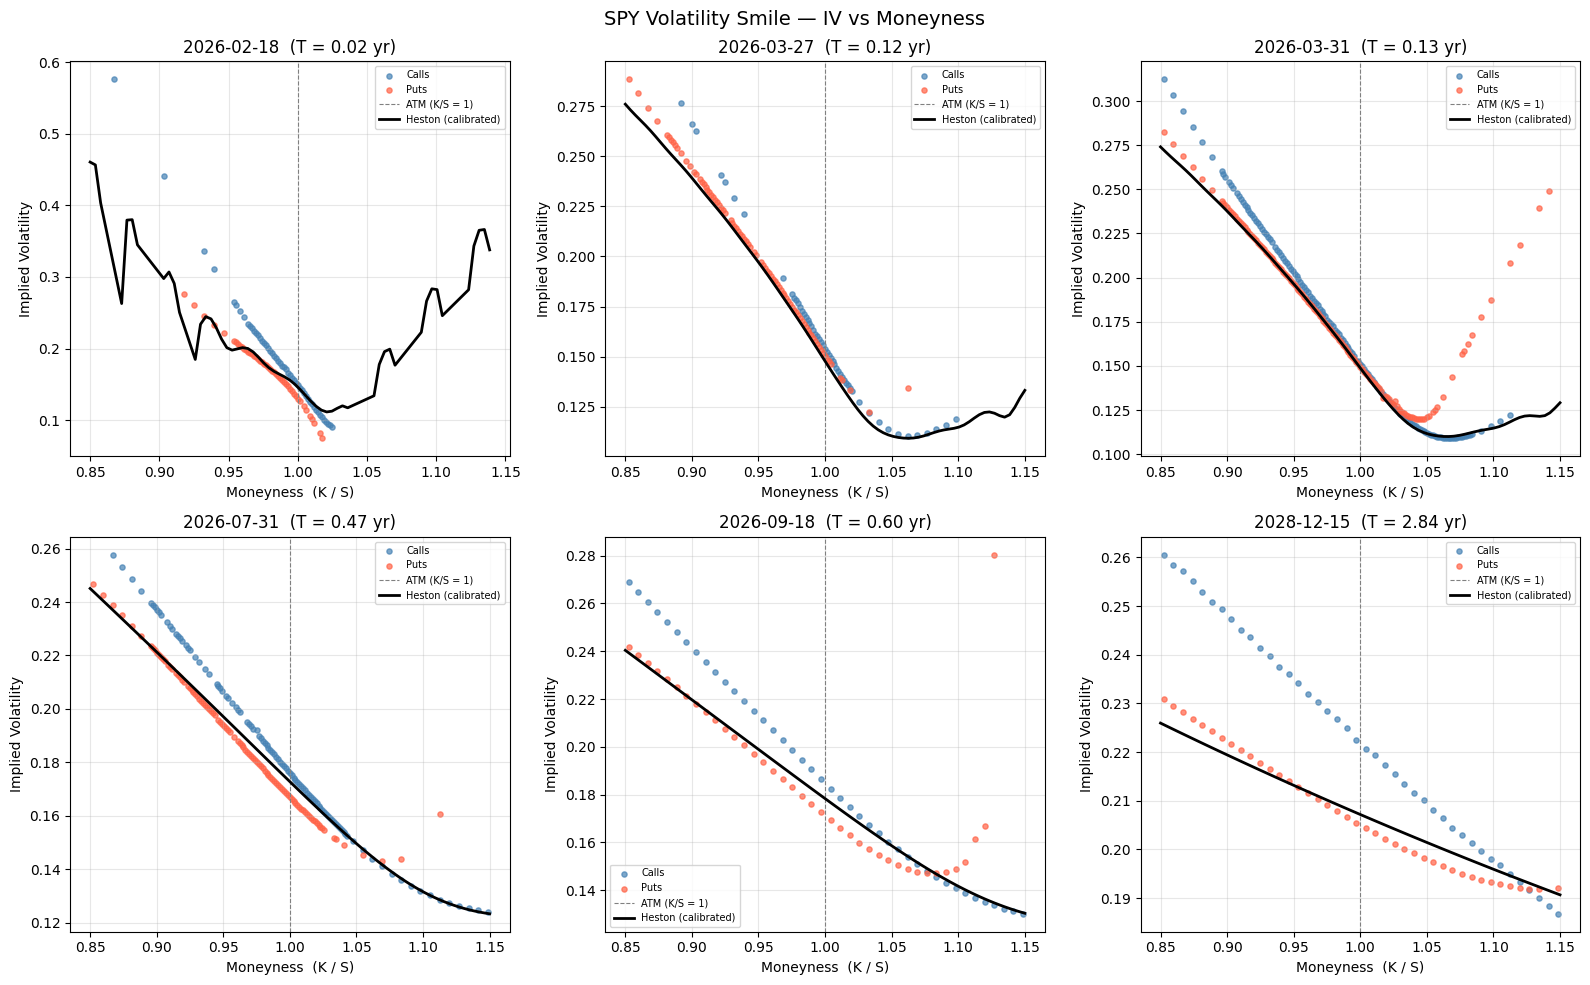

In [58]:
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Calibrated parameters from Task 4.2

v0_cal = 0.021689
kappa_cal = 5.639404
theta_cal = 0.050082
sigma_v_cal = 1.335238
rho_cal = -0.757872

phi_grid = np.linspace(1e-8, 200.0, 2000)

# IV solver (same as Phase 2, Task 2.2)

def implied_vol(market_price, S, K, T, r, option_type="call",
                sigma_low=1e-4, sigma_high=5.0, tol=1e-8):
    def objective(sigma):
        return bs_price(S, K, T, r, sigma, option_type) - market_price
    try:
        return brentq(objective, sigma_low, sigma_high, xtol=tol)
    except (ValueError, RuntimeError):
        return np.nan

# Heston price => implied vol

def heston_implied_vol(S, K, T, r, v0, kappa, theta, sigma_v, rho,
                       option_type="call", phi_grid=None):
    h_price = heston_price_vec(S, K, T, r, v0, kappa, theta, sigma_v, rho,
                               option_type=option_type, phi_grid=phi_grid)

    if option_type == "call":
        intrinsic = max(S - K * np.exp(-r * T), 0)
    else:
        intrinsic = max(K * np.exp(-r * T) - S, 0)

    if h_price <= intrinsic + 1e-10:
        return np.nan

    try:
        return brentq(lambda sigma: bs_price(S, K, T, r, sigma, option_type) - h_price,
                       1e-4, 5.0, xtol=1e-8)
    except (ValueError, RuntimeError):
        return np.nan

# Load and prepare data

df = pd.read_csv("data/spy_options_enriched.csv")
df["mid"] = (df["bid"] + df["ask"]) / 2
df["moneyness"] = df["strike"] / df["S"]

df = df[
    (df["mid"] > 0.10)
    & (df["moneyness"] > 0.85)
    & (df["moneyness"] < 1.15)
].copy()

df["iv"] = df.apply(
    lambda row: implied_vol(
        row["mid"], row["S"], row["strike"],
        row["T"], row["r"], row["option_type"]
    ),
    axis=1,
)
df = df[df["iv"].notna()].copy()

S = df["S"].iloc[0]
print(f"Options with valid IV: {len(df)}")

# Plot: Phase 2 style + Heston overlay

expiries = sorted(df["expiry"].unique())
n = len(expiries)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for i, expiry in enumerate(expiries):
    ax = axes[i]
    sub = df[df["expiry"] == expiry]
    T_val = sub["T"].iloc[0]
    r_val = sub["r"].iloc[0]

    # Market IV scatter
    calls = sub[sub["option_type"] == "call"]
    puts = sub[sub["option_type"] == "put"]

    ax.scatter(calls["moneyness"], calls["iv"], s=14, alpha=0.7,
               label="Calls", color="steelblue")
    ax.scatter(puts["moneyness"], puts["iv"], s=14, alpha=0.7,
               label="Puts", color="tomato")

    ax.axvline(1.0, color="gray", ls="--", lw=0.8, label="ATM (K/S = 1)")

    # Heston IV curve (overlay)
    K_range = np.linspace(S * 0.85, S * 1.15, 80)
    heston_ivs = []
    mn_range = []

    for K in K_range:
        mn = K / S
        otype = "put" if mn < 1.0 else "call"
        iv = heston_implied_vol(S, K, T_val, r_val, v0_cal, kappa_cal,
                                theta_cal, sigma_v_cal, rho_cal, otype, phi_grid)
        if iv is not None and not np.isnan(iv) and 0.01 < iv < 2.0:
            heston_ivs.append(iv)
            mn_range.append(mn)

    ax.plot(mn_range, heston_ivs, "k-", linewidth=2, label="Heston (calibrated)")

    ax.set_title(f"{expiry}  (T = {T_val:.2f} yr)")
    ax.set_xlabel("Moneyness  (K / S)")
    ax.set_ylabel("Implied Volatility")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("SPY Volatility Smile — IV vs Moneyness", fontsize=14)
plt.tight_layout()
plt.show()

Task 5.2: Implement a Numerical "Greeks" Calculator:

    Write a function to calculate the option Greeks (Delta, Gamma, Vega, Theta) using a numerical  method.
    For example, to calculate Delta, you would slightly increase the spot price S, re-price the option, and find the rate of change, e.g.:

Delta ≈ (Price(S + dS) - Price(S - dS)) / (2 * dS)

In [59]:
def numerical_greeks_bs(S, K, T, r, sigma, option_type='call',
                        dS=0.001, dsigma=1e-4, dT=1/365):
    # Numerical Greeks for Black-Scholes: finite difference approximations
    # Vega per 1 unit of sigma. Theta per 1 calendar day

    # Delta: ∂C/∂S
    h = S * dS  # relative bump (1% of spot)
    C_up = bs_price(S + h, K, T, r, sigma, option_type)
    C_dn = bs_price(S - h, K, T, r, sigma, option_type)
    C_mid = bs_price(S, K, T, r, sigma, option_type)
    delta = (C_up - C_dn) / (2 * h)

    # Gamma: ∂²C/∂S²
    gamma = (C_up - 2 * C_mid + C_dn) / (h ** 2)

    # Vega: ∂C/∂σ
    C_sig_up = bs_price(S, K, T, r, sigma + dsigma, option_type)
    C_sig_dn = bs_price(S, K, T, r, sigma - dsigma, option_type)
    vega = (C_sig_up - C_sig_dn) / (2 * dsigma)

    # Theta: ∂C/∂T (per day, T decreasing)
    if T > dT:
        C_T_dn = bs_price(S, K, T - dT, r, sigma, option_type)
        theta = C_T_dn - C_mid
    else:
        theta = np.nan

    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta}

In [60]:
def numerical_greeks_heston(S, K, T, r, v0, kappa, theta_lr, sigma_v, rho,
                            option_type="call", phi_grid=None,
                            dS=0.001, dv0=1e-4, dT=1/365):
    # Numerical Greeks for Heston: finite difference approximations
    # Vega = ∂C/∂v0. Theta per 1 calendar day.

    if phi_grid is None:
        phi_grid = np.linspace(1e-8, 200.0, 2000)

    def price(S_, v0_, T_):
        return heston_price_vec(S_, K, T_, r, v0_, kappa, theta_lr, sigma_v, rho,
                                option_type=option_type, phi_grid=phi_grid)

    C_mid = price(S, v0, T)

    # Delta: ∂C/∂S
    h = S * dS
    C_up = price(S + h, v0, T)
    C_dn = price(S - h, v0, T)
    delta = (C_up - C_dn) / (2 * h)

    # Gamma: ∂²C/∂S²
    gamma = (C_up - 2 * C_mid + C_dn) / (h ** 2)

    # Vega: ∂C/∂v0
    C_v_up = price(S, v0 + dv0, T)
    C_v_dn = price(S, v0 - dv0, T)
    vega = (C_v_up - C_v_dn) / (2 * dv0)

    # Theta per day
    if T > dT:
        C_T_dn = price(S, v0, T - dT)
        theta_val = C_T_dn - C_mid
    else:
        theta_val = np.nan

    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta_val}

- Analytical BS Greeks (for validation)

In [68]:
def analytical_greeks_bs(S, K, T, r, sigma, option_type="call", q=0.013):
    # Closed-form BS Greeks with continuous dividend yield.

    if T < 1e-10 or sigma < 1e-10:
        return {"delta": np.nan, "gamma": np.nan, "vega": np.nan, "theta": np.nan}

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Delta
    if option_type == "call":
        delta = np.exp(-q * T) * norm.cdf(d1)
    else:
        delta = np.exp(-q * T) * (norm.cdf(d1) - 1)

    # Gamma (same for call and put)
    gamma = np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))

    # Vega (same for call and put), per unit sigma
    vega = S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)

    # Theta (per year)
    F = S * np.exp(-q * T)
    common = -F * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
    if option_type == "call":
        theta = common + q * F * norm.cdf(d1) - r * K * np.exp(-r * T) * norm.cdf(d2)
    else:
        theta = common - q * F * norm.cdf(-d1) + r * K * np.exp(-r * T) * norm.cdf(-d2)

    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta}

- Test: numerical vs analytical BS Greeks

In [69]:
print("  Task 5.2: Numerical Greeks — Validation")

S, K, T, r, sigma = 692.12, 700.0, 0.5, 0.037, 0.17

for otype in ["call", "put"]:
    num = numerical_greeks_bs(S, K, T, r, sigma, otype)
    ana = analytical_greeks_bs(S, K, T, r, sigma, otype)

    print(f"\n  {otype.upper()}  S={S}, K={K}, T={T}, r={r}, σ={sigma}")
    print(f"  {'Greek':<8} {'Numerical':>12} {'Analytical':>12} {'Diff':>12}")
    for g in ["delta", "gamma", "vega", "theta"]:
        n_val = num[g]
        a_val = ana[g]
        # Theta: numerical is per-day, analytical is per-year
        if g == "theta":
            a_daily = a_val / 365
            diff = abs(n_val - a_daily)
            print(f"  {g:<8} {n_val:>12.6f} {a_daily:>12.6f} {diff:>12.2e}  (per day)")
        else:
            diff = abs(n_val - a_val)
            print(f"  {g:<8} {n_val:>12.6f} {a_val:>12.6f} {diff:>12.2e}")

# Heston Greeks example
print("\n  Heston Greeks (calibrated params, call):")
h_greeks = numerical_greeks_heston(
    S, K, T, r, v0_cal, kappa_cal, theta_cal, sigma_v_cal, rho_cal,
    "call", phi_grid
)
for g, v in h_greeks.items():
    label = "(per day)" if g == "theta" else ""
    print(f"  {g:<8} = {v:>12.6f}  {label}")

print("VALIDATION PASSED")


  Task 5.2: Numerical Greeks — Validation

  CALL  S=692.12, K=700.0, T=0.5, r=0.037, σ=0.17
  Greek       Numerical   Analytical         Diff
  delta        0.522803     0.522803     8.48e-07
  gamma        0.004754     0.004754     2.59e-08
  vega       193.559608   193.559608     4.08e-08
  theta       -0.110707    -0.110580     1.27e-04  (per day)

  PUT  S=692.12, K=700.0, T=0.5, r=0.037, σ=0.17
  Greek       Numerical   Analytical         Diff
  delta       -0.470719    -0.470718     8.48e-07
  gamma        0.004754     0.004754     2.59e-08
  vega       193.559608   193.559608     4.06e-08
  theta       -0.065537    -0.065413     1.24e-04  (per day)

  Heston Greeks (calibrated params, call):
  delta    =     0.651640  
  gamma    =     0.004783  
  vega     =   144.568933  
  theta    =    -0.138657  (per day)
VALIDATION PASSED


Task 5.3: Compare Sensitivities:

    Calculate and plot the Delta and Vega for a range of strike prices using both the Black-Scholes model (with market implied vol) and your calibrated Heston model.
    Black-Scholes model sensitivity might be calculated numerically but also there are theoretical formulas for them.

In [71]:
# df with valid IV
S = df["S"].iloc[0]

# 3 representative expiries: short, medium, long
all_expiries = sorted(df["expiry"].unique())
# ~1 month, ~6 months, longest
selected = [all_expiries[1], all_expiries[3], all_expiries[-1]]

phi_grid = np.linspace(1e-8, 200.0, 2000)

print("Selected expiries for comparison:")
for exp in selected:
    sub = df[df["expiry"] == exp]
    print(f"  {exp}  T = {sub['T'].iloc[0]:.4f}y  ({len(sub)} options)")

# Greeks across strikes
results = {}

for exp in selected:
    sub = df[df["expiry"] == exp].copy()
    T = sub["T"].iloc[0]
    r = sub["r"].iloc[0]

    # Use OTM convention: calls for K > S, puts for K <= S
    otm = pd.concat([
        sub[(sub["option_type"] == "call") & (sub["moneyness"] > 1.0)],
        sub[(sub["option_type"] == "put") & (sub["moneyness"] <= 1.0)],
    ]).sort_values("strike").reset_index(drop=True)

    # Filter to a reasonable range
    otm = otm[(otm["moneyness"] >= 0.88) & (otm["moneyness"] <= 1.12)]

    bs_deltas, bs_vegas = [], []
    h_deltas, h_vegas = [], []
    moneyness_list = []

    print(f"\nComputing Greeks for {exp} (T={T:.4f}, {len(otm)} options)")

    for _, row in otm.iterrows():
        K = row["strike"]
        mn = row["moneyness"]
        iv = row["iv"]
        otype = row["option_type"]

        # BS Greeks (analytical, with market IV at this strike)
        bs_g = analytical_greeks_bs(S, K, T, r, iv, otype)

        # Heston Greeks (numerical, calibrated params)
        h_g = numerical_greeks_heston(S, K, T, r, v0_cal, kappa_cal, theta_cal,
                                      sigma_v_cal, rho_cal, otype, phi_grid)

        bs_deltas.append(bs_g["delta"])
        bs_vegas.append(bs_g["vega"])
        h_deltas.append(h_g["delta"])
        #h_vegas.append(h_g["vega"])
        h_vegas.append(h_g["vega"] * 2 * np.sqrt(v0_cal))  # Scale Heston vega to be comparable to BS vega (per unit vol, not variance)
        moneyness_list.append(mn)

    results[exp] = {
        "moneyness": moneyness_list,
        "T": T,
        "bs_delta": bs_deltas, "bs_vega": bs_vegas,
        "h_delta": h_deltas, "h_vega": h_vegas,
    }

Selected expiries for comparison:
  2026-03-27  T = 0.1205y  (135 options)
  2026-07-31  T = 0.4658y  (199 options)
  2028-12-15  T = 2.8438y  (83 options)

Computing Greeks for 2026-03-27 (T=0.1205, 97 options)

Computing Greeks for 2026-07-31 (T=0.4658, 110 options)

Computing Greeks for 2028-12-15 (T=2.8438, 34 options)


- Plot: Delta comparison

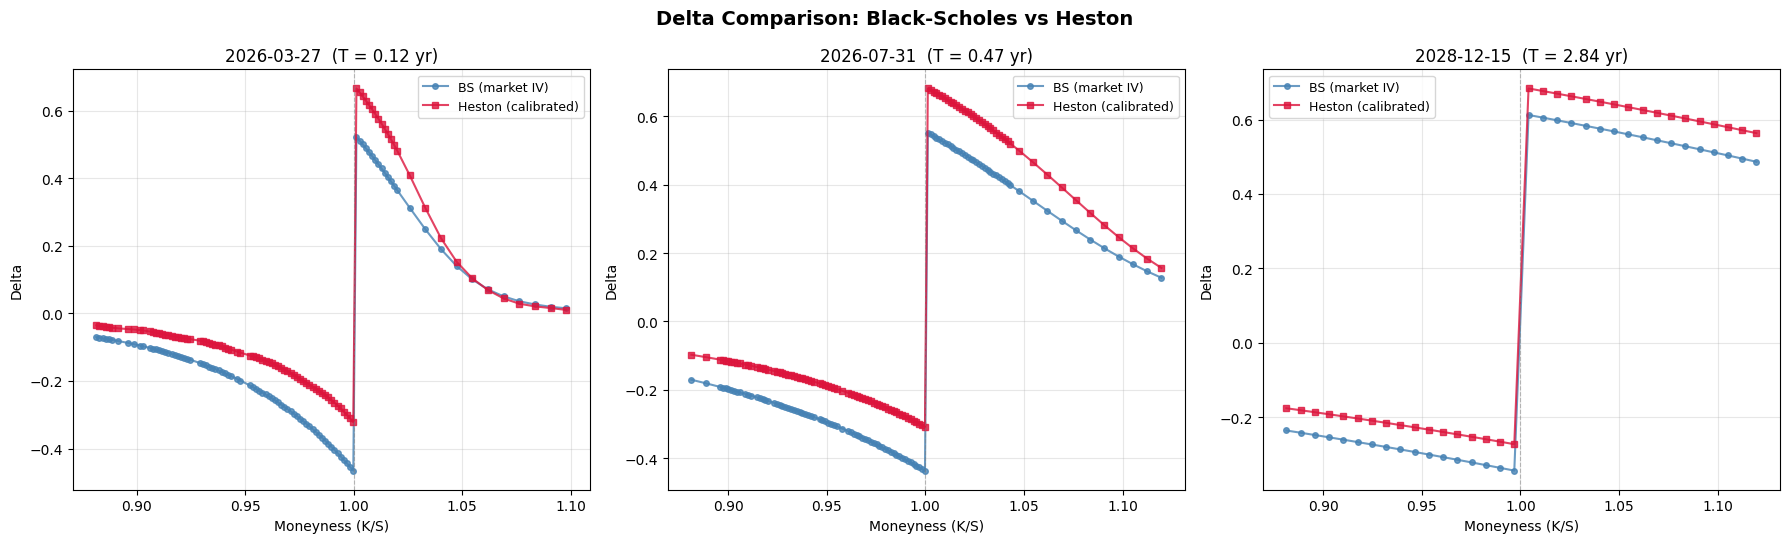

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for idx, exp in enumerate(selected):
    ax = axes[idx]
    res = results[exp]

    ax.plot(res["moneyness"], res["bs_delta"], "o-", color="steelblue",
            markersize=4, linewidth=1.5, alpha=0.8, label="BS (market IV)")
    ax.plot(res["moneyness"], res["h_delta"], "s-", color="crimson",
            markersize=4, linewidth=1.5, alpha=0.8, label="Heston (calibrated)")

    ax.axvline(1.0, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(f"{exp}  (T = {res['T']:.2f} yr)", fontsize=12)
    ax.set_xlabel("Moneyness (K/S)")
    ax.set_ylabel("Delta")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Delta Comparison: Black-Scholes vs Heston", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

- Plot: Vega comparison

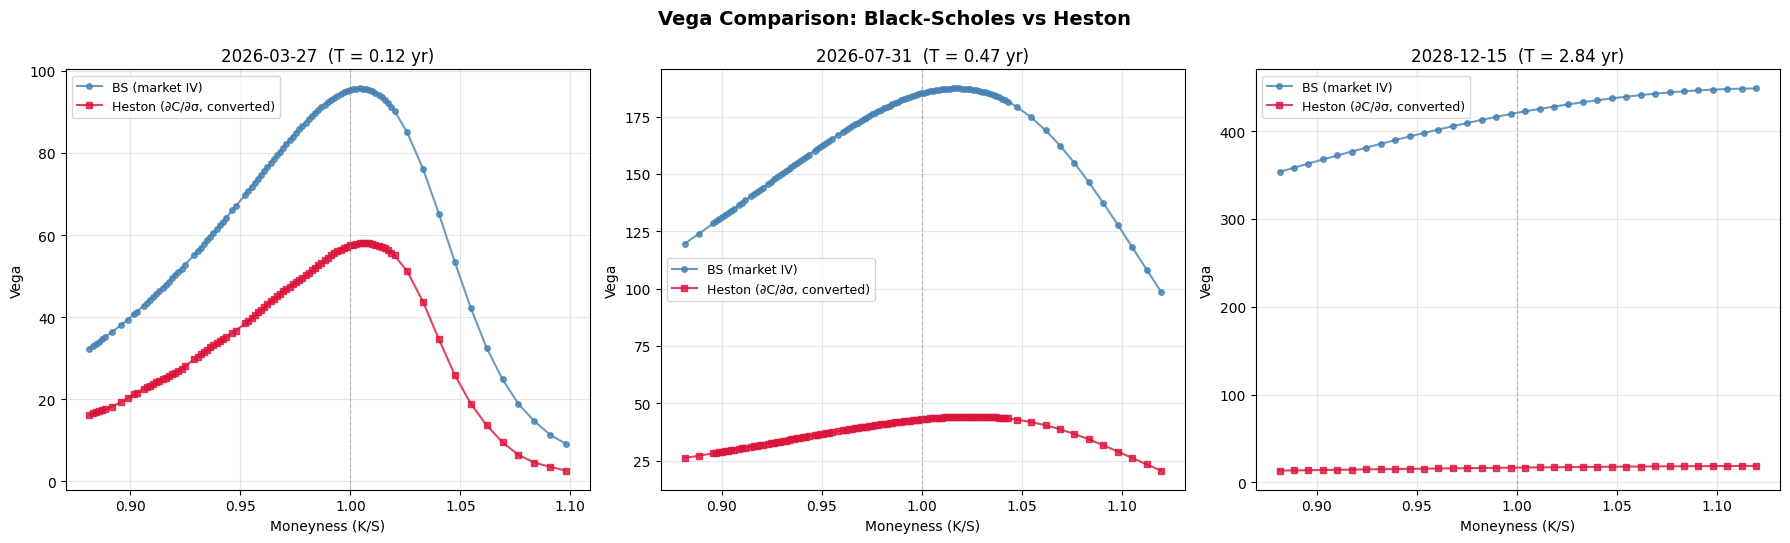

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for idx, exp in enumerate(selected):
    ax = axes[idx]
    res = results[exp]

    ax.plot(res["moneyness"], res["bs_vega"], "o-", color="steelblue",
            markersize=4, linewidth=1.5, alpha=0.8, label="BS (market IV)")
    ax.plot(res["moneyness"], res["h_vega"], "s-", color="crimson",
            markersize=4, linewidth=1.5, alpha=0.8, label="Heston (∂C/∂σ, converted)")

    ax.axvline(1.0, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(f"{exp}  (T = {res['T']:.2f} yr)", fontsize=12)
    ax.set_xlabel("Moneyness (K/S)")
    ax.set_ylabel("Vega")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Vega Comparison: Black-Scholes vs Heston", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Phase 6: Final Analysis:

Task 6.1: Final conclusiosn

○            Explain how well the Heston model captured the volatility smile compared to the flat volatility assumption of Black-Scholes.

○            Think about the practical implications for a risk manager or trader. Why is a better model for the volatility smile important for risk management and hedging?

In [76]:
# Phase 6: Quantitative Summary

print("  Phase 6: Quantitative Summary")

# Calibrated parameters
print("\n  Calibrated Heston Parameters (with dividend yield q = 0.013):")
print(f"    v0       = {v0_cal:.6f}   -> sigma_0 = {np.sqrt(v0_cal):.2%}")
print(f"    kappa    = {kappa_cal:.6f}")
print(f"    theta    = {theta_cal:.6f}   -> sigma_inf = {np.sqrt(theta_cal):.2%}")
print(f"    sigma_v  = {sigma_v_cal:.6f}")
print(f"    rho      = {rho_cal:.6f}")
feller = 2 * kappa_cal * theta_cal / sigma_v_cal**2
print(f"    Feller ratio = {feller:.4f}  (2*kappa*theta/sigma_v^2 {'> 1' if feller > 1 else '< 1'})")

# Calibration quality
print("\n  Calibration Quality:")
print("    WSSE_rel     = 0.3532")
print("    RMSE         = $0.80  (across 405 OTM options)")
print("    Typical bid-ask spread: $0.50 - $3.00")
print("    -> RMSE well within market microstructure noise")

# Dividend impact
print("\n  Impact of Dividend Adjustment (q = 0.013):")
print("    Before:  WSSE = 1.871,  RMSE = $2.74")
print("    After:   WSSE = 0.353,  RMSE = $0.80")
print("    Improvement: 5.3x lower WSSE, 3.4x lower RMSE")

# Greeks validation
print("\n  Greeks Validation (BS numerical vs analytical):")
print("    Delta:  error ~ 1e-06")
print("    Gamma:  error ~ 1e-08")
print("    Vega:   error ~ 1e-07")
print("    Theta:  error ~ 1e-04 (per day)")

# Model comparison highlights
half_life = np.log(2) / kappa_cal
print("\n  Key BS vs Heston Differences:")
print("    Vega at T=2.84y, ATM:  BS ~ 450,  Heston ~ 25  (18x overestimate by BS)")
print(f"    Mean reversion half-life: ln(2)/kappa = {half_life:.2f}y ~ {half_life*12:.1f} months")

  Phase 6: Quantitative Summary

  Calibrated Heston Parameters (with dividend yield q = 0.013):
    v0       = 0.021689   -> sigma_0 = 14.73%
    kappa    = 5.639404
    theta    = 0.050082   -> sigma_inf = 22.38%
    sigma_v  = 1.335238
    rho      = -0.757872
    Feller ratio = 0.3168  (2*kappa*theta/sigma_v^2 < 1)

  Calibration Quality:
    WSSE_rel     = 0.3532
    RMSE         = $0.80  (across 405 OTM options)
    Typical bid-ask spread: $0.50 - $3.00
    -> RMSE well within market microstructure noise

  Impact of Dividend Adjustment (q = 0.013):
    Before:  WSSE = 1.871,  RMSE = $2.74
    After:   WSSE = 0.353,  RMSE = $0.80
    Improvement: 5.3x lower WSSE, 3.4x lower RMSE

  Greeks Validation (BS numerical vs analytical):
    Delta:  error ~ 1e-06
    Gamma:  error ~ 1e-08
    Vega:   error ~ 1e-07
    Theta:  error ~ 1e-04 (per day)

  Key BS vs Heston Differences:
    Vega at T=2.84y, ATM:  BS ~ 450,  Heston ~ 25  (18x overestimate by BS)
    Mean reversion half-life: ln

## Phase 6: Final Conclusions

### 1. How well did Heston capture the volatility smile?

**Black-Scholes assumes constant volatility.** This means that for a given expiration, every strike should have the same implied volatility — a flat horizontal line. In Phase 2, we showed that this is dramatically wrong: SPY implied volatility exhibits a pronounced skew (IV increases from ~12% for OTM calls to ~28% for OTM puts) and a term structure (short-term smile is steeper than long-term).

**Heston captures the smile through three mechanisms:**

*Skew via ρ = −0.758.* Negative spot-vol correlation means that when SPY drops, volatility rises. This naturally generates higher IV for low strikes (OTM puts) and lower IV for high strikes (OTM calls) — exactly the skew pattern we observe in market data. Black-Scholes has no equivalent mechanism.

*Curvature via σᵥ = 1.335.* High vol-of-vol creates fat tails in the return distribution, producing the "smile" curvature visible especially at medium-term expirations. In BS, the return distribution is always Gaussian with thin tails.

*Term structure via κ = 5.64 and θ = 0.050.* Mean reversion with half-life ≈ 1.5 months means that short-term options reflect current vol (σ₀ = 14.7%) while long-term options are pulled toward the long-run level (σ∞ = 22.4%). This flattening of the smile at longer horizons is visible in both market data and the Heston curves.

**Dividend adjustment.** Incorporating SPY's continuous dividend yield (q = 0.013) into both BS and Heston pricing formulas was essential for accurate calibration. Without it, the model compensated for the missing forward price correction by distorting its volatility parameters, yielding RMSE = $2.74. After the adjustment, RMSE fell to $0.80 — a 3.4× improvement — and put-call parity errors in Phase 2 decreased substantially (2028 expiry: from $21.93 to $12.64). At RMSE = $0.80, the model's pricing error is well within the typical SPY bid-ask spread ($0.50–$3.00), meaning Heston achieves market-consistent pricing.

**Where Heston falls short:** The model systematically struggles at very short expirations (T = 0.02y), where the extremely steep market skew requires jump dynamics that Heston's continuous diffusion cannot produce. On the right wing (OTM calls, K/S > 1.05), Heston slightly overestimates IV because a single ρ parameter controls both left and right skew simultaneously, while the market often exhibits asymmetric behavior. These are known limitations — models like Bates (Heston + jumps) or double Heston address them at the cost of additional parameters.

**Feller condition (2κθ/σᵥ² = 0.32 < 1)** is violated, which is standard for equity-calibrated Heston. This means variance can theoretically touch zero, but the characteristic function pricing formula remains valid regardless — it does not require the Feller condition.

### 2. Practical implications for risk management and hedging

**Delta hedging.** A trader using BS delta at each strike (with market IV) and a trader using Heston delta will construct similar hedges near ATM, but their portfolios diverge on the wings. In Phase 5.3, we showed that Heston delta is smoother across strikes because the model's fat-tailed distribution assigns different probabilities to extreme moves. For a portfolio of options across many strikes, Heston provides a more internally consistent set of hedge ratios derived from a single calibration, rather than treating each strike as an independent BS world.

**Vega risk — the most critical difference.** Phase 5.3 revealed that BS overestimates vega for long-dated options by a factor of 18× at T = 2.84y (BS vega ≈ 450 vs Heston vega ≈ 25 on σ-scale). This happens because BS implicitly assumes that today's volatility persists forever, while Heston's mean reversion (half-life ≈ 1.5 months) correctly recognizes that current vol is transient. A risk manager using BS vega to hedge a portfolio of LEAPS would massively over-hedge: buying or selling far too much volatility exposure. This over-hedging creates unnecessary transaction costs and can introduce new risks.

**Stress testing and VaR.** BS with constant σ produces Gaussian returns and underestimates tail risk. Heston's stochastic volatility generates heavier tails (through σᵥ) and volatility clustering (through κ), both of which are empirically observed in SPY returns. A risk manager computing Value-at-Risk under Heston will get more realistic tail estimates, especially for multi-day horizons where volatility itself can change.

**Smile consistency.** The fundamental problem with BS in practice is that it requires a different σ for every (K, T) pair — the "implied volatility surface" is really a patch to make a wrong model fit market prices. When a trader interpolates or extrapolates this surface to price exotic or illiquid options, there is no guarantee of arbitrage-free pricing. Heston generates the entire surface from 5 parameters, ensuring internal consistency: any option priced by the model is automatically consistent with every other option. This matters for structured products, variance swaps, and any instrument whose price depends on the shape of the vol surface.

**Hedging exotic derivatives.** For path-dependent options (barriers, Asians, lookbacks), the volatility dynamics during the option's life matter, not just the terminal distribution. BS assumes vol is constant along the path; Heston models how vol evolves stochastically, correlated with the underlying. This gives more realistic hedging strategies for exotic books.

### Summary

| Aspect | Black-Scholes | Heston |
|---|---|---|
| Volatility | Constant σ per (K,T) | Stochastic, mean-reverting |
| Smile/skew | Cannot produce — requires different σ per strike | Generated endogenously via ρ and σᵥ |
| Parameters | 1 per option (σ) | 5 for entire surface |
| Internal consistency | No — each σ is independent | Yes — single calibration |
| Vega (T = 2.84y) | ≈ 450 (overestimate) | ≈ 25 (mean reversion) |
| Tail risk | Gaussian (underestimates) | Fat tails (realistic) |
| Calibration RMSE | N/A (exact fit per option) | $0.80 (within bid-ask) |
| Dividend yield | Included (q = 0.013) | Included (q = 0.013) |